# 01 — Exploración inicial
## Proyecto final de Machine Learning — Grupo 11
### Dataset: Lending Club Loan Data

**Objetivo de este notebook:** cumplir con la exploración inicial obligatoria de la entrega previa:
carga de datos, tipos y dimensiones, % de faltantes, distribución del target, al menos 5 visualizaciones,
identificación de outliers/registros sospechosos, discusión de sesgos/leakage/limitaciones y un primer baseline simple.

**Nota sobre los datos:** este notebook asume que el archivo `accepted_2007_to_2018Q4.csv.gz`
(o el nombre equivalente del CSV de Lending Club descargado de Kaggle) está ubicado en `data/raw/`.
El dataset no se distribuye en este repositorio por su tamaño (~1.6 GB); debe descargarse manualmente desde
https://www.kaggle.com/datasets/wordsforthewise/lending-club y colocarse en esa ruta (ver `data/README.md`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve
)

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Carga de datos

Dado el tamaño del archivo (~2.2M filas, 140+ columnas), se recomienda:
- Cargar solo un subconjunto de columnas relevantes en una primera pasada, o
- Usar `nrows` / muestreo para la exploración inicial y el pipeline completo para la entrega final.

Aquí se muestra la carga completa de las columnas necesarias para el análisis y el baseline.


In [6]:
DATA_PATH = "../data/raw/accepted_2007_to_2018Q4.csv" # ajustar nombre/ruta real del archivo descargado

# Columnas relevantes: identificador, target, fecha de originación y features "leakage-safe"
USECOLS = [
    "id", "loan_status", "issue_d",
    "loan_amnt", "term", "purpose", "annual_inc", "dti", "emp_length",
    "home_ownership", "verification_status", "fico_range_low", "fico_range_high",
    "open_acc", "total_acc", "revol_bal", "revol_util", "delinq_2yrs",
    "earliest_cr_line", "pub_rec", "inq_last_6mths", "mort_acc",
    "application_type", "addr_state",
    # variables "zona gris" (se analizan aparte, no se incluyen en el baseline)
    "grade", "sub_grade", "int_rate",
]

df = pd.read_csv(DATA_PATH, usecols=USECOLS, low_memory=False)
df.shape


(2260701, 27)

## 2. Definición de la variable objetivo

Se colapsa `loan_status` en una variable binaria y se excluyen los préstamos cuyo desenlace
aún no está definido (`Current`, `In Grace Period`, `Late (16-30 days)`, `Late (31-120 days)`),
para evitar sesgo de censura (ver `proposal.md`, sección 5 y 8).


In [7]:
print("Distribución original de loan_status:")
print(df["loan_status"].value_counts(dropna=False))

MALOS = ["Charged Off", "Default"]
BUENOS = ["Fully Paid"]

df_model = df[df["loan_status"].isin(MALOS + BUENOS)].copy()
df_model["target"] = df_model["loan_status"].isin(MALOS).astype(int)

print(f"\nFilas excluidas por estado no definitivo: {len(df) - len(df_model):,}")
print(f"Filas para modelado: {len(df_model):,}")


Distribución original de loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

Filas excluidas por estado no definitivo: 915,351
Filas para modelado: 1,345,350


## 3. Número de filas, columnas y tipos de datos

In [8]:
print(f"Shape (post-filtro de target): {df_model.shape}")
df_model.dtypes.value_counts()


Shape (post-filtro de target): (1345350, 28)


float64    14
str        13
int64       1
Name: count, dtype: int64

In [9]:
df_model.dtypes.astype(str).sort_values().to_frame(name="dtype")

,dtype
loan_amnt,float64
int_rate,float64
total_acc,float64
revol_util,float64
revol_bal,float64
pub_rec,float64
annual_inc,float64
open_acc,float64
inq_last_6mths,float64
fico_range_high,float64


## 4. Porcentaje de valores faltantes por variable

In [10]:
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.to_frame(name="% faltante")


,% faltante
emp_length,5.836102
mort_acc,3.514401
revol_util,0.063701
dti,0.027799
inq_last_6mths,0.000074


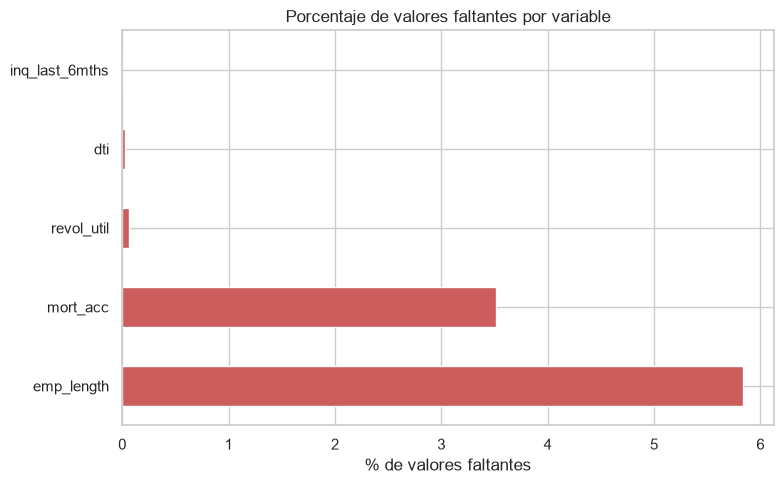

In [11]:
# Visualización 1: % de faltantes por variable
fig, ax = plt.subplots(figsize=(8, 5))
missing_pct.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Porcentaje de valores faltantes por variable")
plt.tight_layout()
plt.show()


## 5. Distribución de la variable objetivo

target
0    80.035009
1    19.964991
Name: proportion, dtype: float64


C:\Users\JOSSEMY-PC\AppData\Local\Temp\ipykernel_31496\1434509479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df_model, ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\JOSSEMY-PC\AppData\Local\Temp\ipykernel_31496\1434509479.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Bueno (Fully Paid)", "Malo (Default/Charged Off)"])


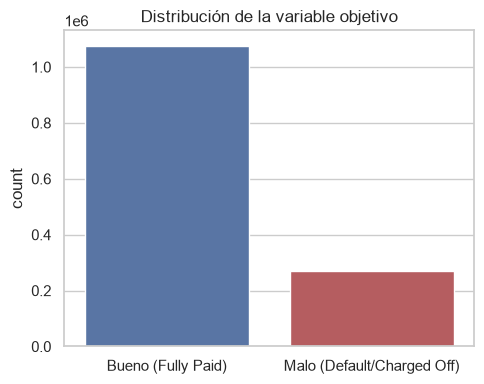

In [12]:
target_counts = df_model["target"].value_counts(normalize=True) * 100
print(target_counts)

# Visualización 2: distribución del target
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="target", data=df_model, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Bueno (Fully Paid)", "Malo (Default/Charged Off)"])
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


**Lectura esperada:** se anticipa un fuerte desbalance de clases (~15-20% de préstamos en default/charged off),
lo cual justifica usar AUC-PR y KS como métricas principales en vez de accuracy (ver `proposal.md`, sección 9).


## 6. Visualizaciones adicionales

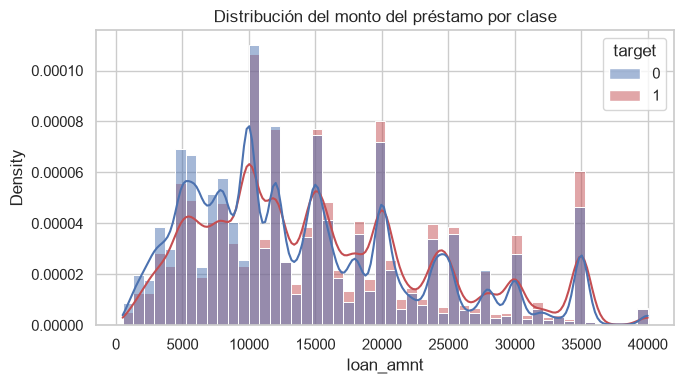

In [13]:
# Visualización 3: distribución de loan_amnt por clase
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_model, x="loan_amnt", hue="target", bins=50, kde=True, ax=ax,
             palette=["#4C72B0", "#C44E52"], stat="density", common_norm=False)
ax.set_title("Distribución del monto del préstamo por clase")
plt.tight_layout()
plt.show()


C:\Users\JOSSEMY-PC\AppData\Local\Temp\ipykernel_31496\684857000.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Bueno", "Malo"])


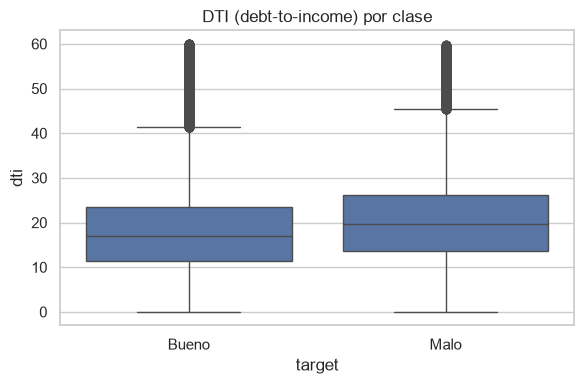

In [14]:
# Visualización 4: dti (debt-to-income) por clase (boxplot, con recorte de outliers extremos)
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="target", y="dti", data=df_model[df_model["dti"].between(0, 60)], ax=ax)
ax.set_xticklabels(["Bueno", "Malo"])
ax.set_title("DTI (debt-to-income) por clase")
plt.tight_layout()
plt.show()


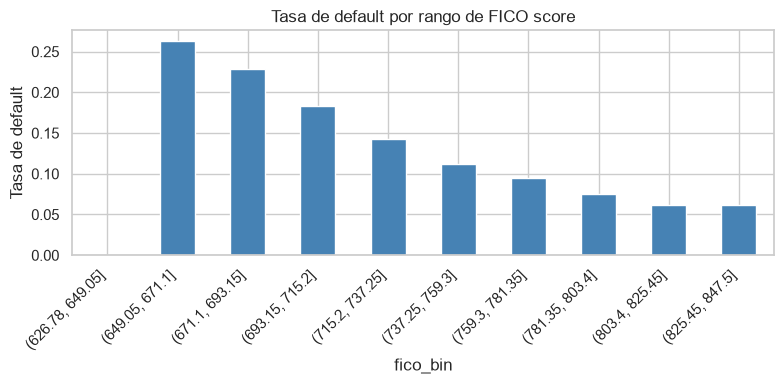

In [15]:
# Visualización 5: tasa de default por rango de FICO
df_model["fico_avg"] = (df_model["fico_range_low"] + df_model["fico_range_high"]) / 2
df_model["fico_bin"] = pd.cut(df_model["fico_avg"], bins=10)

fico_default_rate = df_model.groupby("fico_bin", observed=True)["target"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
fico_default_rate.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Tasa de default")
ax.set_title("Tasa de default por rango de FICO score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


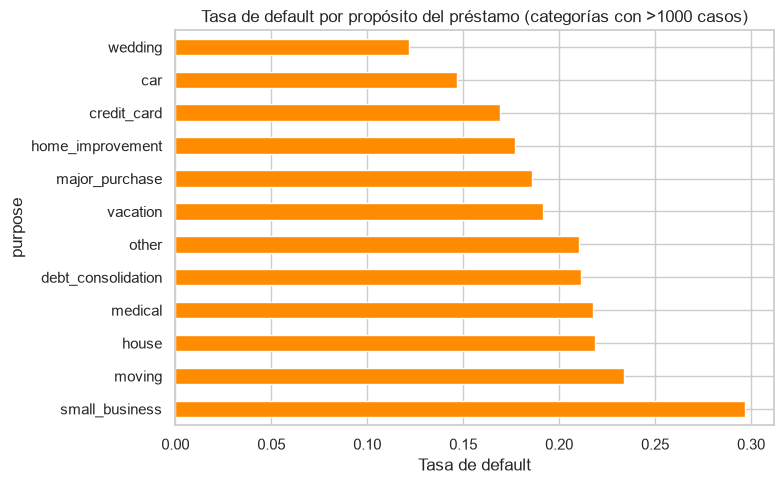

In [16]:
# Visualización 6: tasa de default por propósito del préstamo
purpose_default = df_model.groupby("purpose")["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
purpose_default = purpose_default[purpose_default["count"] > 1000]  # descartar categorías con muy pocos casos

fig, ax = plt.subplots(figsize=(8, 5))
purpose_default["mean"].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("Tasa de default")
ax.set_title("Tasa de default por propósito del préstamo (categorías con >1000 casos)")
plt.tight_layout()
plt.show()


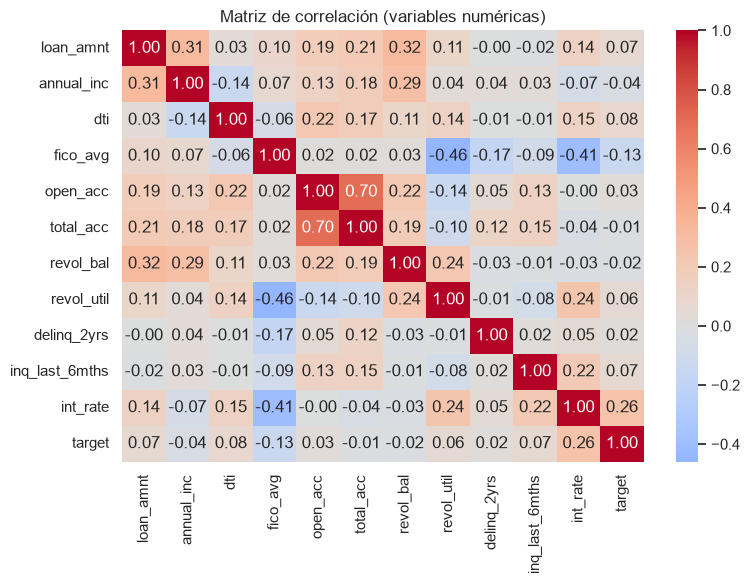

In [17]:
# Visualización 7: matriz de correlación entre variables numéricas
num_cols = ["loan_amnt", "annual_inc", "dti", "fico_avg", "open_acc",
            "total_acc", "revol_bal", "revol_util", "delinq_2yrs",
            "inq_last_6mths", "int_rate", "target"]

corr = df_model[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()


## 7. Identificación de outliers y registros sospechosos

Se revisan valores extremos o inconsistentes en variables clave.


In [18]:
print("annual_inc — estadísticos:")
print(df_model["annual_inc"].describe())
print(f"\nPréstamos con annual_inc > $1,000,000: {(df_model['annual_inc'] > 1_000_000).sum():,}")

print("\ndti — estadísticos:")
print(df_model["dti"].describe())
print(f"\nPréstamos con dti negativo (inconsistente): {(df_model['dti'] < 0).sum():,}")
print(f"Préstamos con dti > 100 (sospechoso): {(df_model['dti'] > 100).sum():,}")

print(f"\nPréstamos con revol_util > 150% (posible error de captura): {(df_model['revol_util'] > 150).sum():,}")


annual_inc — estadísticos:
count    1.345350e+06
mean     7.624757e+04
std      6.992485e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

Préstamos con annual_inc > $1,000,000: 290

dti — estadísticos:
count    1.344976e+06
mean     1.828264e+01
std      1.116041e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64

Préstamos con dti negativo (inconsistente): 2
Préstamos con dti > 100 (sospechoso): 533

Préstamos con revol_util > 150% (posible error de captura): 20


**Decisión preliminar:** los registros con `annual_inc` extremo (>$1M) o `dti` fuera de rango razonable
(negativo o >100) se tratarán como candidatos a exclusión o a winsorización en la etapa de limpieza
(`02_limpieza_features.ipynb`), documentando el criterio y el número de filas afectadas.


## 8. Discusión inicial de sesgos, leakage y limitaciones

**Leakage:**
- Se excluyeron explícitamente todas las variables generadas después del desembolso del préstamo
  (`total_pymnt`, `recoveries`, `last_pymnt_d`, `hardship_*`, `settlement_*`, etc.), ya que revelan directamente el desenlace.
- `grade`, `sub_grade` e `int_rate` se mantienen como "zona gris": están disponibles al momento de originación,
  pero son producto del propio modelo de scoring de Lending Club. Se entrenará con y sin estas variables
  para medir cuánto del desempeño depende de "copiar" la decisión de LC.

**Sesgos:**
- El dataset solo contiene préstamos **aprobados** por Lending Club (no hay información de solicitudes rechazadas),
  por lo que cualquier modelo entrenado aquí hereda el sesgo de selección del proceso de aprobación original.
- Variables como `addr_state` o `home_ownership` pueden actuar como proxies de variables socioeconómicas
  sensibles; se documentará si el modelo genera disparidades relevantes por segmento en el análisis de errores.
- El comportamiento de default varía por ciclo económico (ej. prestamos originados antes/durante la crisis
  de 2008-2009 vs. después); esto motiva el split temporal (out-of-time) descrito en `proposal.md`.
- **Evidencia concreta de este drift en nuestros datos:** la tasa de default en el set de entrenamiento (préstamos originados 2015-2017) fue de **21.9%**, mientras que en el set de validación (originados en 2018) fue de **15.8%**. Esta diferencia de ~6 puntos porcentuales confirma que el comportamiento de pago no es estable en el tiempo, y refuerza por qué la validación debe ser out-of-time (temporal) y no aleatoria: un split aleatorio hubiera mezclado ambos regímenes y ocultado este problema.

**Limitaciones:**
- No se dispone de las solicitudes rechazadas, por lo que no se puede modelar el proceso de aprobación completo,
  solo el riesgo condicional a haber sido aprobado.
- Variables de texto libre (`emp_title`, `desc`) no se usarán en el baseline por su alta cardinalidad y ruido;
  se evaluará su potencial en iteraciones posteriores.


## 9. Baseline simple

Regresión logística con las variables "incluidas" (sin `grade`/`sub_grade`/`int_rate`), split **temporal**
(no aleatorio) usando `issue_d`, siguiendo el plan de validación de `proposal.md`.


In [19]:
df_model["issue_d"] = pd.to_datetime(df_model["issue_d"], format="%b-%Y")
df_model["issue_year"] = df_model["issue_d"].dt.year

train = df_model[df_model["issue_year"].between(2015, 2017)]
valid = df_model[df_model["issue_year"] == 2018]

print(f"Train: {len(train):,} filas | Valid: {len(valid):,} filas")
print(f"Tasa de default train: {train['target'].mean():.3f} | valid: {valid['target'].mean():.3f}")


Train: 837,972 filas | Valid: 56,318 filas
Tasa de default train: 0.219 | valid: 0.158


In [20]:
FEATURES_NUM = ["loan_amnt", "annual_inc", "dti", "fico_avg", "open_acc",
                "total_acc", "revol_bal", "revol_util", "delinq_2yrs",
                "inq_last_6mths", "mort_acc"]
FEATURES_CAT = ["term", "purpose", "emp_length", "home_ownership",
                "verification_status", "application_type"]

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train["target"]
X_valid, y_valid = valid[FEATURES_NUM + FEATURES_CAT], valid["target"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), FEATURES_NUM),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CAT),
])

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

baseline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['loan_amnt','annual_inc','dti',...,'home_ownership','verification_status', 'application_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [21]:
y_pred_proba = baseline.predict_proba(X_valid)[:, 1]
y_pred = baseline.predict(X_valid)

print(f"AUC-ROC: {roc_auc_score(y_valid, y_pred_proba):.3f}")
print(f"AUC-PR (métrica principal): {average_precision_score(y_valid, y_pred_proba):.3f}")
print()
print(classification_report(y_valid, y_pred, target_names=["Bueno", "Malo"]))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_valid, y_pred))


AUC-ROC: 0.683
AUC-PR (métrica principal): 0.271

              precision    recall  f1-score   support

       Bueno       0.90      0.69      0.78     47444
        Malo       0.26      0.57      0.35      8874

    accuracy                           0.67     56318
   macro avg       0.58      0.63      0.57     56318
weighted avg       0.79      0.67      0.71     56318


Matriz de confusión:
[[32789 14655]
 [ 3845  5029]]


**Lectura inicial:** este resultado es el piso de comparación honesto para el proyecto.
En las siguientes iteraciones se compararán modelos de árboles y gradient boosting contra este baseline,
y se evaluará el efecto de incluir las variables "zona gris" (`grade`, `sub_grade`, `int_rate`).
